In [63]:
import sys
sys.path.insert(0, "/Users/jackson/Library/CloudStorage/OneDrive-UniversityofTennessee/University of Tennessee/Talmy lab/MCMCwithODEs_primer-v0.1.0")
from utils.plot_utils_v2 import *
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt

In [64]:
import pandas as pd
import numpy as np

## Cell 1 ##
dataset = pd.read_csv('data/ehux379_d7.csv')
dataset=dataset.loc[(dataset['exp'] == 5) & (dataset['d7_present'] == 1)]

# All units are in cells/mL

ehux_live_density = dataset['ehux'].values
ehux_live_time = dataset['time'].values
log_ehux_live_density = np.log(ehux_live_density + 1e-9)

ehux_dead_density = dataset['sytox+'].values
ehux_death_time = dataset['time'].values
log_ehux_dead_density = np.log(ehux_dead_density + 1e-9)

bacteria_density = dataset['bacteria'].values
bacteria_time = dataset['time'].values
log_bacteria_density = np.log(bacteria_density + 1e-9)

In [65]:
## Cell 2 ##

def general_case(t, y, params):
    P, D, B = y
    mu_P = params[0]
    k_P = params[1]
    delta_P = params[2]
    mu_B = params[3]
    k_B = params[4]
    beta_B = params[5]
    rho = params[6]
    lambda_D = params[7]
    phi_B = rho * D

    dPdt = mu_P * P * (1-P/k_P) - delta_P * P - phi_B * P * B
    dDdt = delta_P * P + phi_B * P * B - lambda_D * D
    dBdt = mu_B * B * (1-B/k_B) + beta_B * phi_B * P * B
   
    return [dPdt, dDdt, dBdt]

Here is where this case becomes unique. This ODE system is stiff. This happens when rates of change within a system vary drastically. This will cause the process to lock up if you don't use a proper sampler / solver. Here is how we chose to solve the issue. 

We are still going to use PyMC, however, instead of using the integrated solver we will use an external SciPy ODE solver to get around the stiffness issue. We declare a custom operator (**Op**) with one input vector (**itypes**) and one output matrix (**otypes**). It will be initialized with your observed times. **perform** is the default call for the runtime computation of the **Op**. See in Cell 5 how the parameters and inital values are passed to the **Op**. The first 4 are the parameters and last 3 are the initial conditions (**theta** and **y0**).

The solve_ivp call should follow this form. The inputs to the function are as follows:

**fun**: The ODE function(s)  
**t_span**: first and last time  
**y0**: Initial Values  
**t_eval**: exact time points the ODE will be evaluated at  
**method**: This is up to the user but for our case we chose LSODA. It auto-detects stiffness and switches between Adams (non-stiff) and BDF (stiff) methods.

Lastly, the output is transposed to match the form PyMC expects. 

In [66]:
## Cell 3 ##


import pytensor.tensor as pt
from pytensor.graph.op import Op
from scipy.integrate import solve_ivp


class SolveIVPWrapper(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, t_obs_list, n_params=8, rtol=1e-6, atol=1e-8, penalty=1e8):
        self.t_obs_list = [np.asarray(t, dtype=float) for t in t_obs_list]
        self.n_params = n_params
        self.rtol = rtol
        self.atol = atol
        self.penalty = penalty

        self.t_grid = np.unique(np.concatenate(self.t_obs_list))
        self.t_span = (self.t_grid.min(), self.t_grid.max())
        self._total_len = sum(len(t) for t in self.t_obs_list)

    def _solve(self, params, y0, method):
        try:
            return solve_ivp(
                general_case, self.t_span, y0,
                t_eval=self.t_grid, method=method, args=(params,),
                rtol=self.rtol, atol=self.atol,
            )
        except Exception:
            return None

    def perform(self, node, inputs, outputs):
        (theta_y0,) = inputs
        params = theta_y0[: self.n_params]
        y0 = theta_y0[self.n_params:]

        sol = self._solve(params, y0, "LSODA")
        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            sol = self._solve(params, y0, "BDF")

        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            outputs[0][0] = np.full(self._total_len, self.penalty)
            return

        preds = [np.interp(t, self.t_grid, sol.y[i]) for i, t in enumerate(self.t_obs_list)]
        outputs[0][0] = np.concatenate(preds)

# class SolveIVPWrapper(Op):
#     itypes = [pt.dvector]  # theta + y0
#     otypes = [pt.dmatrix]  # solution: (len(t), 3)

#     def __init__(self, times):
#         self.times = times

#     def perform(self, node, inputs, outputs):
#         theta_y0, = inputs
#         theta = theta_y0[:8]    # Parameter values
#         y0 = theta_y0[8:]       # T0 values

#         sol = solve_ivp(
#             fun=lambda t, y: general_case(t, y, theta),
#             t_span=(self.times[0], self.times[-1]),
#             y0=y0,
#             t_eval=self.times,
#             method="LSODA"
#         )

#         if not sol.success:
#             raise RuntimeError("ODE solver failed:", sol.message)

#         outputs[0][0] = sol.y.T  # shape: (time, 3)

This is where we create the MCMC 'loop': Sample Priors -> Estimate ODE @ times -> check fit

First, proirs. You have all kinds of options. Uniform, normal, lognormal, halfnormal. It all depends on what you need. For our parameters we choose uniform priors. These uniform priors say, "we believe the proper value for the model will be equally likely within this range and WILL NOT be outside of it". For our initial conditions we choose a lognormal distribution. This says, "we believe our value is around some **x** given a normalesque strictly positive distribution". For our sigma terms (error), we choose a halfnormal distribution. This is usually used for your error or standard deviation since neither can be negative and you can tune how quickly it tails off. Below are the priors visualized. 

<img src="../../figures/priors_c3.png" width="450"/>

After the priors are declared the next function call will be for the solution of the model given its current estimates. Pay attention to the order in which you pass your priors!

The final functions are the likelihood estimations of the model's states. This is where the model tests how well it estimated the observed data. We pass it our log transformed estimated data, the sigma values from the iteration's sample, and log transformed observed data. Now just let PyMC simply work its magic!

In [ ]:
## Cell 5 ##

import pymc as pm

n1, n2, n3 = len(ehux_live_time), len(ehux_death_time), len(bacteria_time)

ode_op = SolveIVPWrapper(t_obs_list=[ehux_live_time, ehux_death_time, bacteria_time])


with pm.Model() as model:
    mu_P     = pm.LogNormal("mu_P",     mu=np.log(4.4668e-01), sigma=0.4)
    k_P      = pm.LogNormal("k_P",      mu=np.log(4.3652e+06), sigma=0.4)
    delta_P  = pm.LogNormal("delta_P",  mu=np.log(7.4131e-02), sigma=0.4)
    mu_B     = pm.LogNormal("mu_B",     mu=np.log(4.8978e-01), sigma=0.4)
    k_B      = pm.LogNormal("k_B",      mu=np.log(4.3652e+07), sigma=0.4)
    beta_B   = pm.LogNormal("beta_B",   mu=np.log(4.0500e+00), sigma=0.4)
    rho      = pm.LogNormal("rho",      mu=np.log(2.1878e-14),  sigma=0.4)
    lambda_D = pm.LogNormal("lambda_D", mu=np.log(4.8978e-01), sigma=0.4)

    P0 = pm.LogNormal("P0", mu=np.log(1.2303e+05), sigma=0.4)
    D0 = pm.LogNormal("D0", mu=np.log(1.9226e+04), sigma=0.4)
    B0 = pm.LogNormal("B0", mu=np.log(1.3804e+05), sigma=0.4)

    # sigma_live = pm.HalfNormal("sigma_live", 0.3)
    # sigma_dead = pm.HalfNormal("sigma_dead", 0.69)
    # sigma_bacteria = pm.HalfNormal("sigma_bacteria", 0.69)

    sigma_live = 0.3 * np.log(10)
    sigma_dead = 0.3 * np.log(10)
    sigma_bacteria = 0.3 * np.log(10)

    theta_y0 = pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, P0, D0, B0])
    preds = ode_op(theta_y0)

    live     = preds[:n1]
    dead     = preds[n1:n1 + n2]
    bacteria = preds[n1 + n2:]

    pm.Normal("Y_live", mu=pm.math.log(live + 1e-9), sigma=sigma_live, observed=log_ehux_live_density)
    pm.Normal("Y_dead", mu=pm.math.log(dead + 1e-9), sigma=sigma_dead, observed=log_ehux_dead_density)
    pm.Normal("Y_bacteria", mu=pm.math.log(bacteria + 1e-9), sigma=sigma_bacteria, observed=log_bacteria_density)


# Origional code, doesn't allow for solving of replicates
# ode_op = SolveIVPWrapper(ehux_live_time)

# with pm.Model() as model:
#     mu_P     = pm.Uniform(  "mu_P", 0.1, 3)
#     k_P      = pm.LogNormal("k_P",      mu=np.log(7.762e+6), sigma=0.4)
#     delta_P  = pm.LogNormal("delta_P",  mu=np.log(5.012e-2), sigma=0.4)
#     mu_B     = pm.Uniform(  "mu_B", 0.2, 5)
#     k_B      = pm.LogNormal("k_B",      mu=np.log(1.096e+7), sigma=0.4)
#     beta_B   = pm.LogNormal("beta_B",   mu=np.log(2.512e+1), sigma=0.6)
#     rho      = pm.LogNormal("rho",      mu=np.log(7.413e-14), sigma=0.4)
#     lambda_D = pm.LogNormal("lambda_D", mu=np.log(3.020e-1), sigma=0.4)


#     P0 = pm.LogNormal("P0", mu=np.log(3e5), sigma=0.5)
#     D0 = pm.LogNormal("D0", mu=np.log(5e4), sigma=0.5)
#     B0 = pm.LogNormal("B0", mu=np.log(6e4), sigma=0.8)

#     sigma_live = pm.HalfNormal("sigma_live", 1)
#     sigma_dead = pm.HalfNormal("sigma_dead", 1)
#     sigma_bacteria = pm.HalfNormal("sigma_bacteria", 1)

#     # Solve ODE
#     sol = ode_op(pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, P0, D0, B0]))

#     live = sol[:, 0]
#     dead = sol[:, 1]
#     bacteria = sol[:, 2]

#     pm.Normal("Y_live", mu=pm.math.log(live + 1e-9), sigma=sigma_live, observed=log_ehux_live_density)
#     pm.Normal("Y_dead", mu=pm.math.log(dead + 1e-9), sigma=sigma_dead, observed=log_ehux_dead_density)
#     pm.Normal("Y_bacteria", mu=pm.math.log(bacteria + 1e-9), sigma=sigma_bacteria, observed=log_bacteria_density)

This is how you call and run the model!

**draws**: poterior values to be generated.  
**tune**: Some under the hood PyMC magic that 'warms it up'. Keep this between 500 and 2000 depending on how complex your model is.  
**chains / cores**: Amount of chains you want to compute in parallel. Keep these values the same for most basic usage. PyMC recommends you run at least 4 chains.    
**step**: By default PyMC uses NUTS (No U-Turn Sampler). If you want to use something other than NUTS this is where you declare it.  
**return_inferencedata**: returns an ARVIZ inferencedata object which we'll use for easy reading of our output.  

In [68]:
## Cell 6 ##

with model:
    trace = pm.sample(draws=30000, 
                      tune=15000, 
                      chains=4, 
                      cores=4,
                      step=pm.DEMetropolisZ(),
                      return_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, P0, D0, B0]


Output()

Sampling 4 chains for 15_000 tune and 30_000 draw iterations (60_000 + 120_000 draws total) took 95 seconds.


To interpret the output we have some user-defined postprocessing and plotting functions. They are in our GitHub repo.

Sampling: [B0, D0, P0, Y_bacteria, Y_dead, Y_live, beta_B, delta_P, k_B, k_P, lambda_D, mu_B, mu_P, rho]


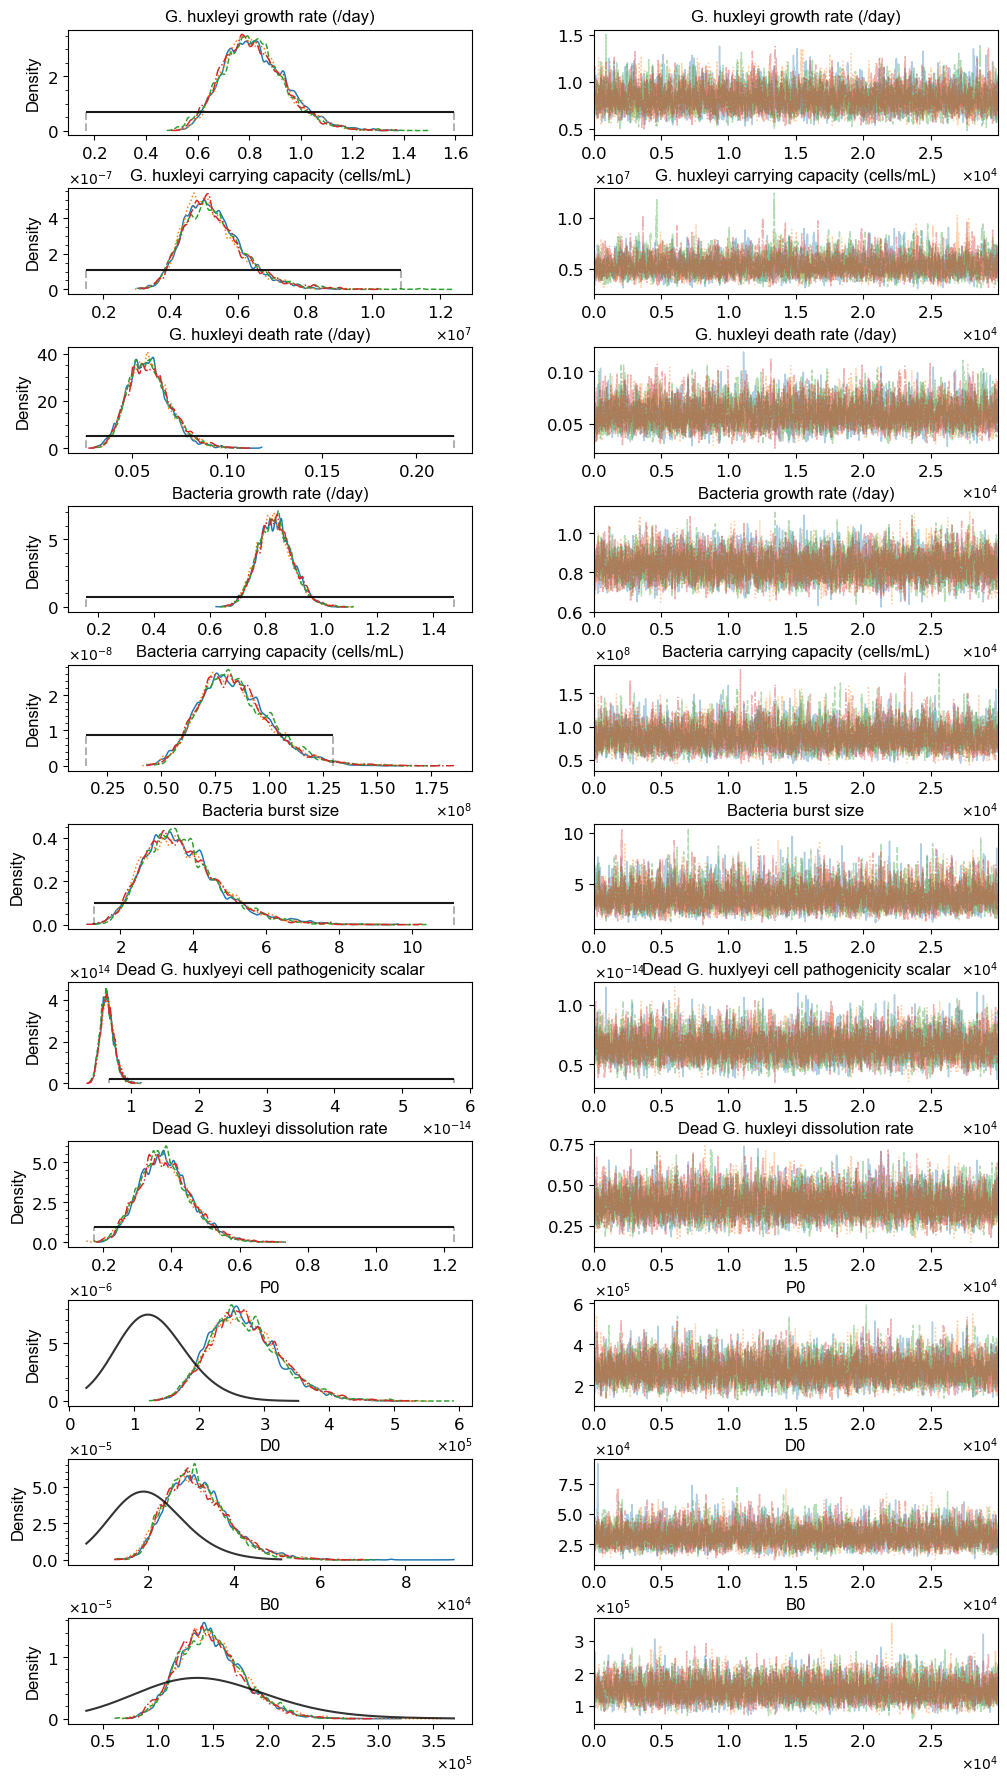

In [73]:
plot_trace(trace=trace,
           model=model,
           uni=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D'],
           fontname='Arial',
           fontsize=12,
           num_prior_samples=2000,
           var_names_map={'mu_P': 'G. huxleyi growth rate (/day)', 'k_P': 'G. huxleyi carrying capacity (cells/mL)', 'delta_P': 'G. huxleyi death rate (/day)', 'mu_B': 'Bacteria growth rate (/day)', 'k_B': 'Bacteria carrying capacity (cells/mL)', 'beta_B': 'Bacteria burst size', 'rho': 'Dead G. huxlyeyi cell pathogenicity scalar', 'lambda_D': 'Dead G. huxleyi dissolution rate'},
           var_order=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D', 'P0', 'D0', 'B0', 'sigma_live','sigma_dead', 'sigma_bacteria'],
           save_path='figures/vardi_general_chains_reparam.png')
plt.show()

In [74]:
def case_3_posteriors(trace, ehux_total_time, ehux_death_time, bacteria_time,
                       ehux_total_density, ehux_dead_density, bacteria_density,
                       general_case, ode_solution2data):
    n_samples = 500
    burn_in = 0

    # ---------- 1) Pre-compute once, avoid .flatten() in the loop ----------
    posterior = trace.posterior.stack(draws=("chain", "draw"))

    # Pull 1-D numpy views once (zero copy where possible)
    to_1d = lambda name: np.asarray(posterior[name].values).reshape(-1)

    mu_P_all     = to_1d("mu_P")
    k_P_all      = to_1d("k_P")
    delta_P_all  = to_1d("delta_P")
    mu_B_all     = to_1d("mu_B")
    k_B_all      = to_1d("k_B")
    beta_B_all   = to_1d("beta_B")
    rho_all      = to_1d("rho")
    lambda_D_all = to_1d("lambda_D")

    P0_all = to_1d("P0")
    D0_all = to_1d("D0")
    B0_all = to_1d("B0")

    available_draws = mu_P_all.shape[0]
    assert burn_in + n_samples <= available_draws, "Not enough samples"

    # Pick the exact indices we'll use (no Python increments in the loop)
    idxs = np.arange(burn_in, burn_in + n_samples)

    # ---------- 2) Time grid computed once ----------
    t_min = float(min(ehux_total_time.min(), ehux_death_time.min(), bacteria_time.min()))
    t_max = float(max(ehux_total_time.max(), ehux_death_time.max(), bacteria_time.max()))
    t_eval = np.linspace(t_min, t_max, 200)

    # ---------- 3) Solve ODEs with args= (avoids per-iter lambda) ----------
    # general_case signature must be: general_case(t, y, params)
    # We'll pass theta via args=(theta,) into solve_ivp.

    from scipy.integrate import solve_ivp

    # Choose a method suited to your system (try 'BDF' if stiff; otherwise 'DOP853' is fast/accurate)
    METHOD = "BDF"           # try "DOP853" if non-stiff
    RTOL, ATOL = 1e-6, 1e-6  # consider 1e-5 / 1e-5 for more speed

    # ---------- 4) Collect curves, plot once via LineCollection (much cheaper) ----------
    live_segments    = []
    dead_segments     = []
    bacteria_segments = []

    for idx in idxs:
        theta = [
            mu_P_all[idx], k_P_all[idx], delta_P_all[idx],
            mu_B_all[idx], k_B_all[idx], beta_B_all[idx],
            rho_all[idx], lambda_D_all[idx]
        ]
        y0 = [P0_all[idx], D0_all[idx], B0_all[idx]]

        sol = solve_ivp(
            fun=general_case,
            t_span=(t_eval[0], t_eval[-1]),
            y0=y0,
            t_eval=t_eval,
            rtol=RTOL,
            atol=ATOL,
            method=METHOD,
            args=(theta,),
            dense_output=False,    # faster; you already supply t_eval
            vectorized=False       # set True only if general_case supports vectorization
        )
        if not sol.success:
            continue

        s = ode_solution2data(sol.y.T)  # expects shape (len(t_eval), nstates) -> {"total","dead","bacteria"}

        # Build polyline segments for a single efficient draw call per subplot
        live_segments.append(np.column_stack((t_eval, s["live"]))[:, None, :])
        dead_segments.append(np.column_stack((t_eval, s["dead"]))[:, None, :])
        bacteria_segments.append(np.column_stack((t_eval, s["bacteria"]))[:, None, :])

    # If nothing solved, bail early
    if len(live_segments) == 0:
        raise RuntimeError("All ODE solves failed.")

    live_segments    = np.concatenate(live_segments, axis=1).transpose(1, 0, 2)  # (n_lines, n_pts, 2)
    dead_segments     = np.concatenate(dead_segments, axis=1).transpose(1, 0, 2)
    bacteria_segments = np.concatenate(bacteria_segments, axis=1).transpose(1, 0, 2)

    # ---------- 5) Plot: one collection per panel instead of hundreds of Line2D ----------
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
    labels = ["Total G. huxleyi cells (/ml)", "Dead G. huxleyi cells (/ml)", "Bacteria (/ml)"]

    # Total
    lc0 = LineCollection(live_segments, linewidths=1.0, alpha=0.05)
    axes[0].add_collection(lc0)
    axes[0].autoscale_view()

    # Dead
    lc1 = LineCollection(dead_segments, linewidths=1.0, alpha=0.05)
    axes[1].add_collection(lc1)
    axes[1].autoscale_view()

    # Bacteria
    lc2 = LineCollection(bacteria_segments, linewidths=1.0, alpha=0.05)
    axes[2].add_collection(lc2)
    axes[2].autoscale_view()

    # Observed data overlays (single scatter calls)
    axes[0].scatter(ehux_total_time, ehux_total_density, c="k", s=20, zorder=3)
    axes[1].scatter(ehux_death_time, ehux_dead_density, c="k", s=20, zorder=3)
    axes[2].scatter(bacteria_time, bacteria_density, c="k", s=20, zorder=3)

    # Titles and formatting (no legend spam)
    for i, ax in enumerate(axes):
        ax.set_title(labels[i])
        ax.set_xlabel("Time (days)", fontsize=12)
        ax.set_ylabel("Density", fontsize=12)
        ax.set_yscale('log')
        ax.tick_params(labelsize=11)

    plt.tight_layout()
    plt.show()


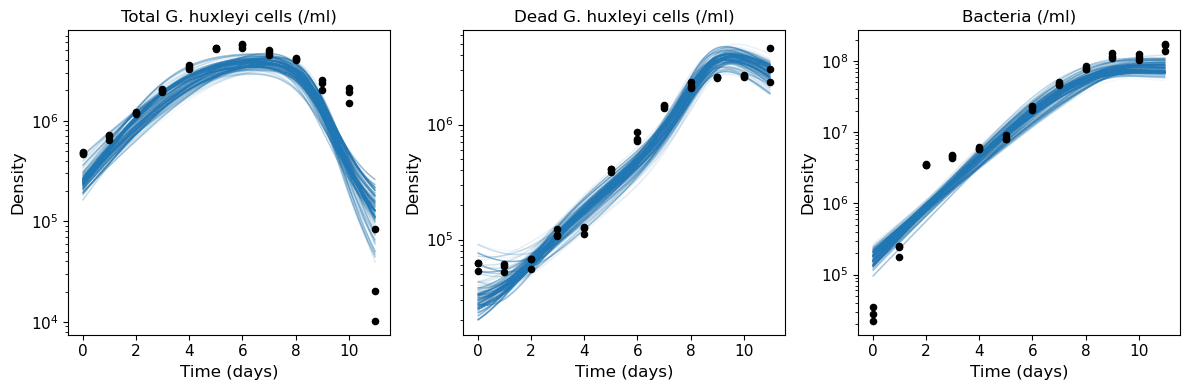

In [71]:
def ode_solution2data(solution):
    live = solution[:, 0]
    dead = solution[:, 1]
    bacteria = solution[:, 2]
    return {
        "live": live,
        "dead": dead,
        'bacteria': bacteria
    }

case_3_posteriors(trace, 
                  ehux_live_time, 
                  ehux_death_time,
                  bacteria_time,
                  ehux_live_density, 
                  ehux_dead_density, 
                  bacteria_density,
                  general_case, 
                  ode_solution2data)

In [75]:
import arviz as az
# print(az.summary(trace, var_names=['sigma_live','sigma_dead','sigma_bacteria']))
# compare medians to 0.3*np.log(10) ≈ 0.69 (converting old code's log10 sigma=0.3 to natural-log scale)

print(az.summary(trace, var_names=['mu_P','k_P','delta_P','rho']))
# if r_hat > 1.05 / ess_bulk < 100 here specifically, that's the non-identifiability from missing mono data

                mean          sd       hdi_3%      hdi_97%  mcse_mean  \
mu_P           0.821       0.122        0.602        1.056      0.003   
k_P      5288394.548  924190.160  3688086.662  6999278.262  19731.327   
delta_P        0.059       0.011        0.039        0.081      0.000   
rho            0.000       0.000        0.000        0.000      0.000   

           mcse_sd  ess_bulk  ess_tail  r_hat  
mu_P         0.002    2386.0    3839.0    1.0  
k_P      14221.993    2383.0    3281.0    1.0  
delta_P      0.000    2869.0    5278.0    1.0  
rho          0.000    3033.0    5435.0    1.0  


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, P0, D0, B0]


Output()

Sampling 4 chains for 15_000 tune and 30_000 draw iterations (60_000 + 120_000 draws total) took 97 seconds.
Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, phi_const, lambda_D, P0, D0, B0]


Output()

Sampling 4 chains for 15_000 tune and 30_000 draw iterations (60_000 + 120_000 draws total) took 122 seconds.
Sampling: [B0, D0, P0, Y_bacteria, Y_dead, Y_live, beta_B, delta_P, k_B, k_P, lambda_D, mu_B, mu_P, rho]


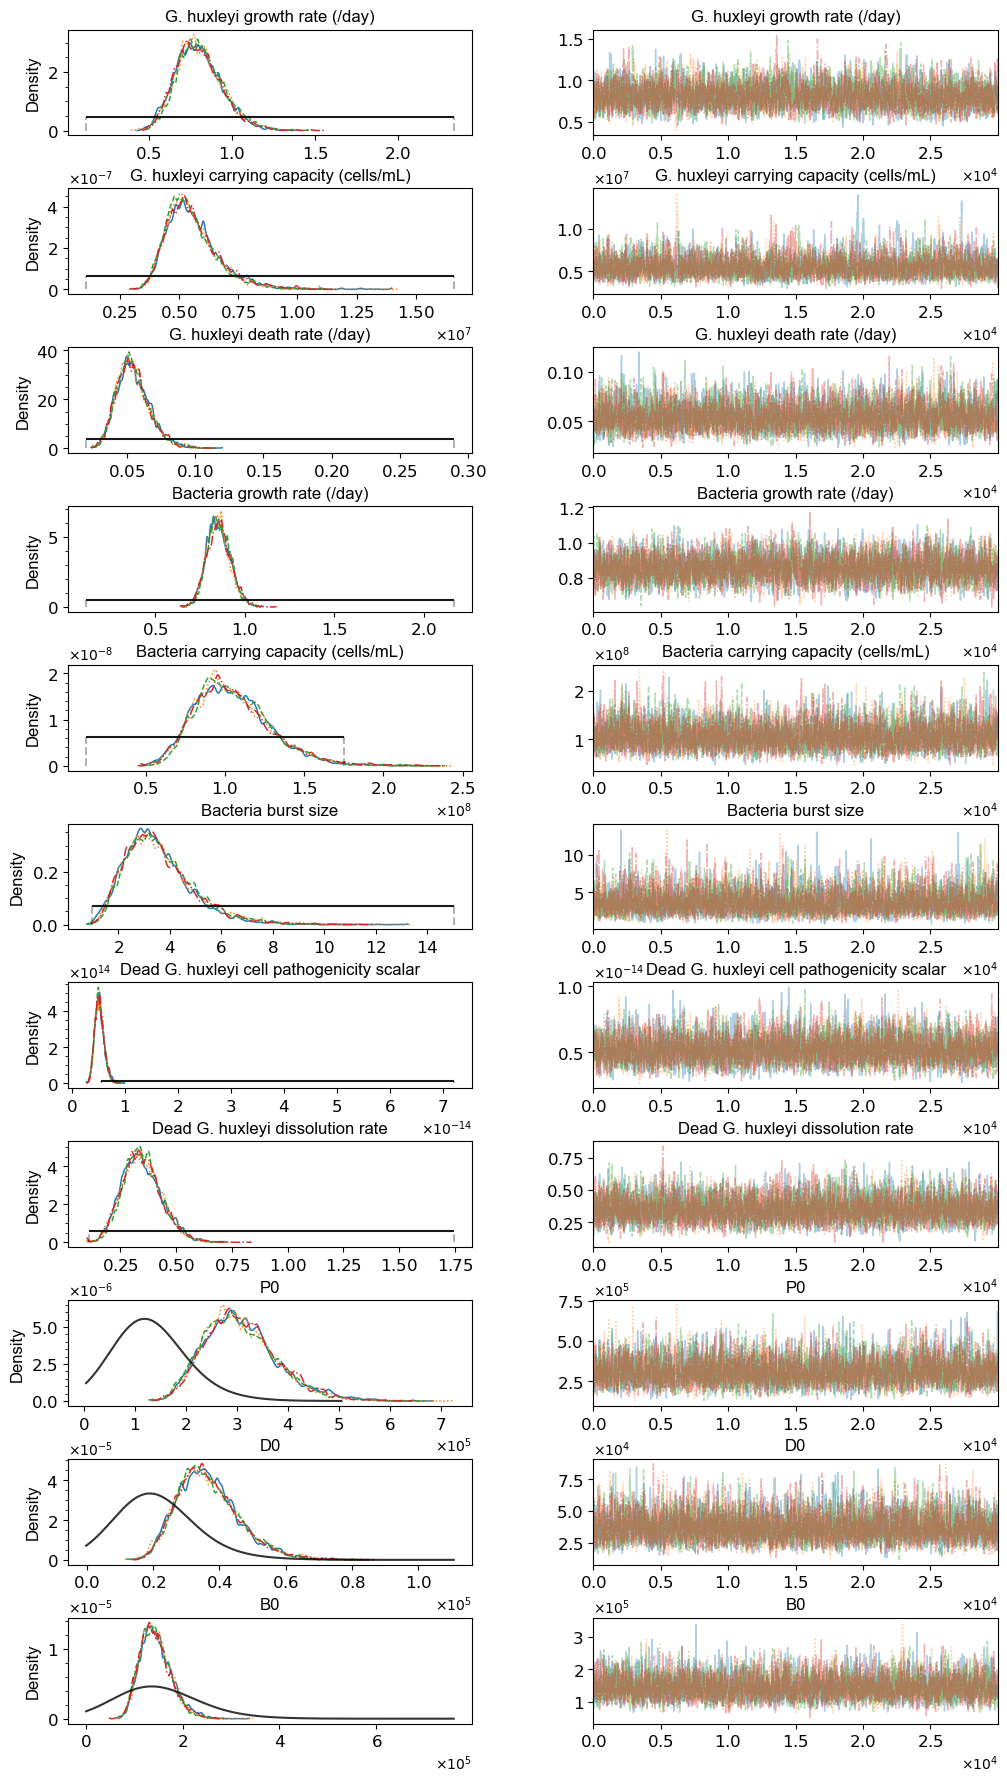

Sampling: [B0, D0, P0, Y_bacteria, Y_dead, Y_live, beta_B, delta_P, k_B, k_P, lambda_D, mu_B, mu_P, phi_const]


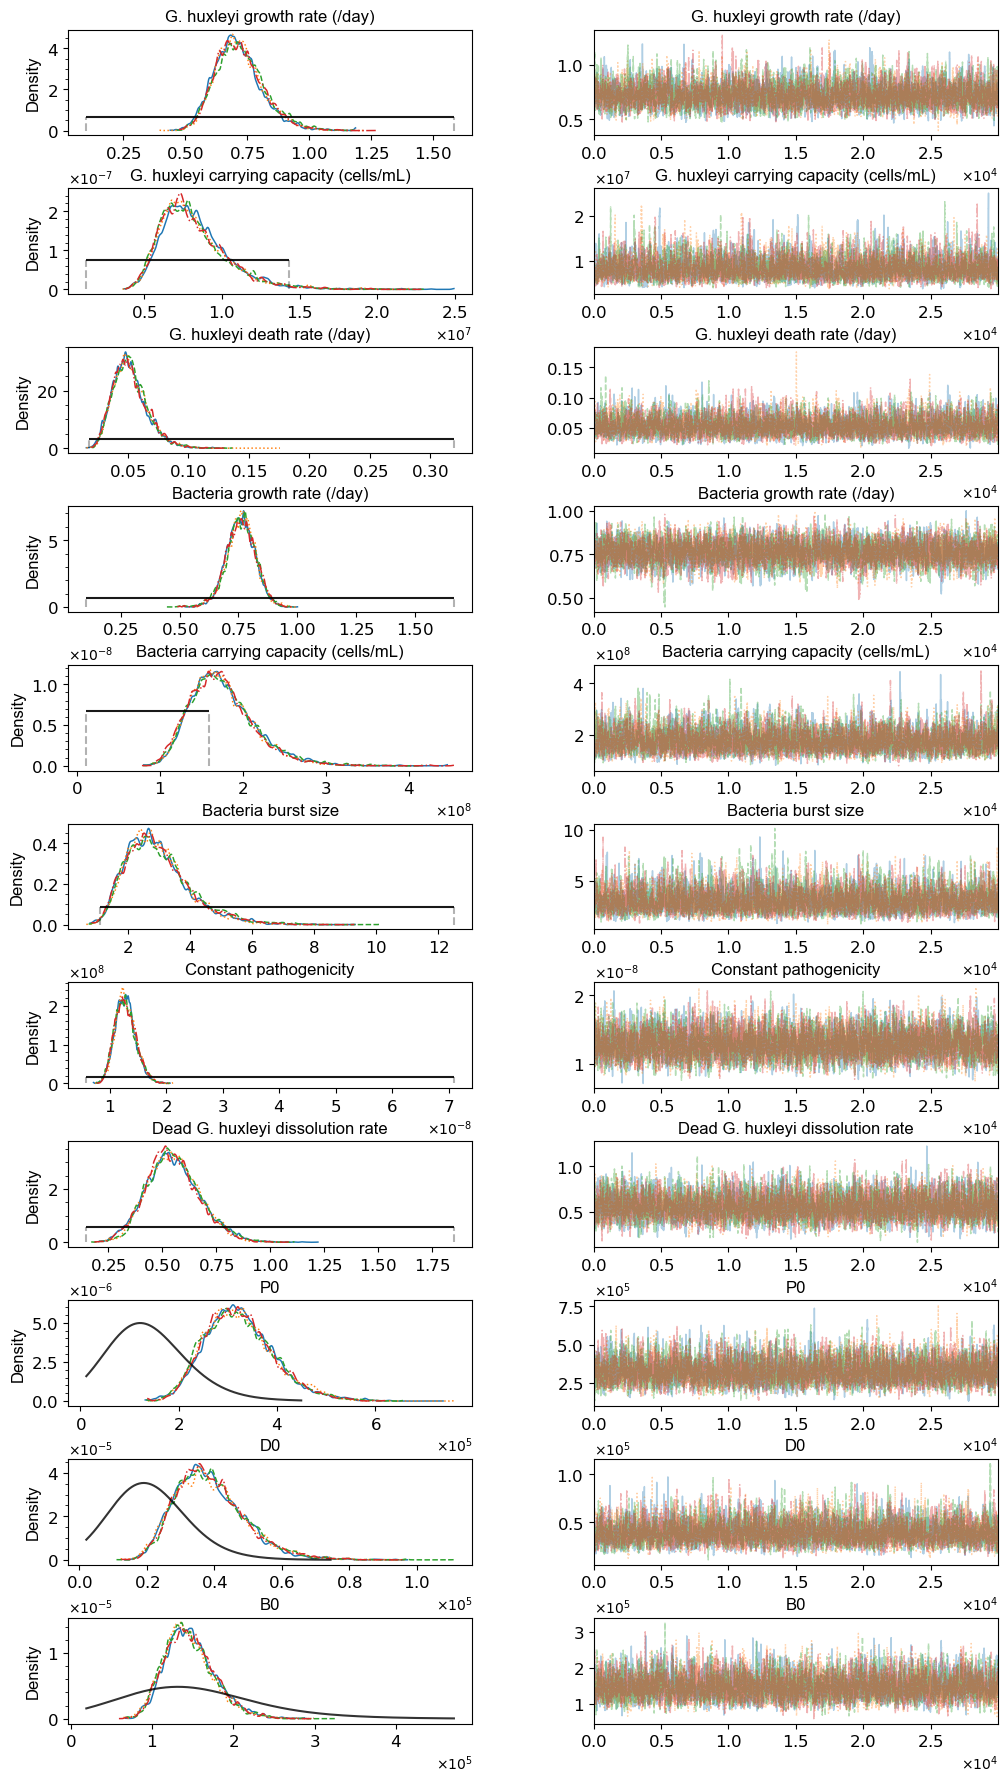

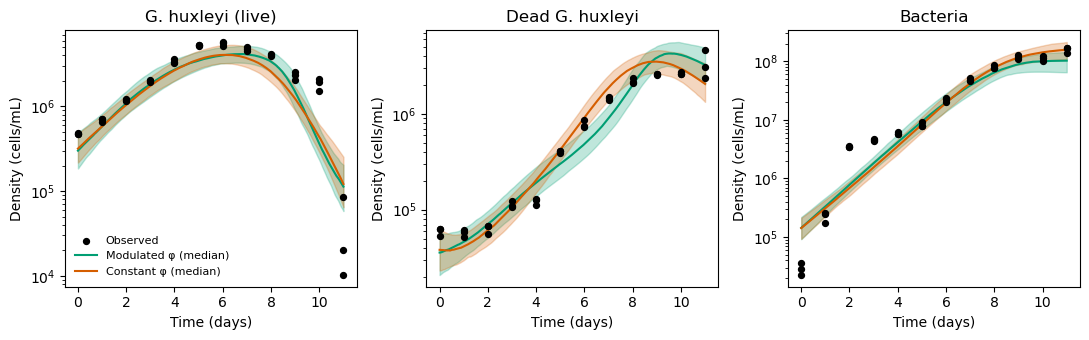

Modulated φ  -- mean: -108.30   median: -108.04   SD: 3.30
Constant φ   -- mean: -109.26   median: -109.05   SD: 3.51
Delta median (mod - const): 1.01


/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_36681/2001384912.py:394: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ll_df, x='Model', y='Log-likelihood', palette=[COLOR_MOD, COLOR_CONST], inner='box', ax=ax)


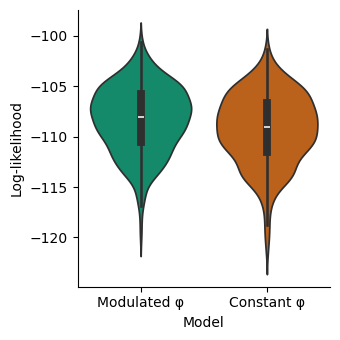


Optimal parameters (posterior median) -- Modulated φ
  mu_P         7.918218e-01
  k_P          5.382034e+06
  delta_P      5.294857e-02
  mu_B         8.503184e-01
  k_B          1.022709e+08
  beta_B       3.384754e+00
  rho          5.113946e-15
  lambda_D     3.409695e-01
  P0           2.995223e+05
  D0           3.554064e+04
  B0           1.409821e+05

Optimal parameters (posterior median) -- Constant φ
  mu_P         7.108966e-01
  k_P          7.818032e+06
  delta_P      5.037095e-02
  mu_B         7.614268e-01
  k_B          1.704755e+08
  beta_B       2.817302e+00
  phi_const    1.266504e-08
  lambda_D     5.450237e-01
  P0           3.179911e+05
  D0           3.756547e+04
  B0           1.430319e+05

Saved to data/optimal_params_mod.json and data/optimal_params_const.json


In [79]:
# %%
import sys
sys.path.insert(0, "/Users/jackson/Library/CloudStorage/OneDrive-UniversityofTennessee/University of Tennessee/Talmy lab/MCMCwithODEs_primer-v0.1.0")
from utils.plot_utils_v2 import *
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt

# %%
import pandas as pd
import numpy as np

## Cell 1 ##
EXP_ID = 5  # default fit target; set to 4 to run the comparison case

df = pd.read_csv('data/ehux379_d7.csv')
df = df.loc[(df['exp'] == EXP_ID) & (df['d7_present'] == 1)]

# All units are in cells/mL
# NOTE: no groupby/averaging -- raw triplicate rows kept intact so the
# likelihood sees genuine replicate scatter, not a collapsed mean.

ehux_live_density = df['ehux'].values
ehux_live_time = df['time'].values
log_ehux_live_density = np.log(ehux_live_density + 1e-9)

ehux_dead_density = df['sytox+'].values
ehux_death_time = df['time'].values
log_ehux_dead_density = np.log(ehux_dead_density + 1e-9)

bacteria_density = df['bacteria'].values
bacteria_time = df['time'].values
log_bacteria_density = np.log(bacteria_density + 1e-9)

n1, n2, n3 = len(ehux_live_time), len(ehux_death_time), len(bacteria_time)

# %%
## Cell 2 -- ODE systems: modulated phi (rho * D) vs constant phi ##

def general_case(t, y, params):
    """Modulated pathogenicity: phi_B = rho * D."""
    P, D, B = y
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D = params
    phi_B = rho * D

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B
    dDdt = delta_P * P + phi_B * P * B - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    return [dPdt, dDdt, dBdt]


def general_case_const(t, y, params):
    """Constant pathogenicity: phi_B = phi_const (fixed, not modulated by D)."""
    P, D, B = y
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, phi_const, lambda_D = params
    phi_B = phi_const

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B
    dDdt = delta_P * P + phi_B * P * B - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    return [dPdt, dDdt, dBdt]

# %%
## Cell 3 ##

import pytensor.tensor as pt
from pytensor.graph.op import Op
from scipy.integrate import solve_ivp


class SolveIVPWrapper(Op):
    """
    theta_y0 = [<8 ODE params>, P0, D0, B0]

    Generalized to accept any ode_func with signature ode_func(t, y, params)
    so the same Op class serves both the modulated and constant-phi models --
    only the RHS callable and the 7th parameter's meaning differ between them.

    Solves ONCE on the union of every stream's raw observation times, then
    interpolates back out to each stream's own raw (unsorted, duplicated --
    triplicates) timestamps. Tries LSODA first, falls back to BDF, and on
    total failure (or a non-finite solution) returns a large-but-finite
    penalty vector instead of raising, so a bad MCMC proposal just gets
    rejected via low likelihood instead of crashing the whole chain.
    """

    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, ode_func, t_obs_list, n_params=8, rtol=1e-6, atol=1e-8, penalty=1e8):
        self.ode_func = ode_func
        self.t_obs_list = [np.asarray(t, dtype=float) for t in t_obs_list]
        self.n_params = n_params
        self.rtol = rtol
        self.atol = atol
        self.penalty = penalty

        self.t_grid = np.unique(np.concatenate(self.t_obs_list))
        self.t_span = (self.t_grid.min(), self.t_grid.max())
        self._total_len = sum(len(t) for t in self.t_obs_list)

    def _solve(self, params, y0, method):
        try:
            return solve_ivp(
                self.ode_func, self.t_span, y0,
                t_eval=self.t_grid, method=method, args=(params,),
                rtol=self.rtol, atol=self.atol,
            )
        except Exception:
            return None

    def perform(self, node, inputs, outputs):
        (theta_y0,) = inputs
        params = theta_y0[: self.n_params]
        y0 = theta_y0[self.n_params:]

        sol = self._solve(params, y0, "LSODA")
        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            sol = self._solve(params, y0, "BDF")

        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            outputs[0][0] = np.full(self._total_len, self.penalty)
            return

        preds = [np.interp(t, self.t_grid, sol.y[i]) for i, t in enumerate(self.t_obs_list)]
        outputs[0][0] = np.concatenate(preds)


ode_op_mod = SolveIVPWrapper(general_case, t_obs_list=[ehux_live_time, ehux_death_time, bacteria_time])
ode_op_const = SolveIVPWrapper(general_case_const, t_obs_list=[ehux_live_time, ehux_death_time, bacteria_time])

# %%
## Cell 4 -- fixed sigma (isolation-test result: keep fixed, not fitted) ##
#
# sigma_live/dead/bacteria are FIXED, not sampled -- see prior conversation.
# Free HalfNormal sigmas let the sampler inflate noise to explain misfit
# instead of forcing the ODE parameters to track the data; fixing sigma
# resolved r-hat/ESS problems and tightened the fit substantially.

SIGMA_FIXED = 0.3 * np.log(10)  # ~0.6908, natural-log equiv. of old log10-scale sigma=0.3

# %%
## Cell 5 -- Model A: modulated pathogenicity (phi_B = rho * D) ##

import pymc as pm

with pm.Model() as model_mod:
    mu_P     = pm.LogNormal("mu_P",     mu=np.log(4.4668e-01), sigma=0.4)
    k_P      = pm.LogNormal("k_P",      mu=np.log(4.3652e+06), sigma=0.4)
    delta_P  = pm.LogNormal("delta_P",  mu=np.log(7.4131e-02), sigma=0.4)
    mu_B     = pm.LogNormal("mu_B",     mu=np.log(4.8978e-01), sigma=0.4)
    k_B      = pm.LogNormal("k_B",      mu=np.log(4.3652e+07), sigma=0.4)
    beta_B   = pm.LogNormal("beta_B",   mu=np.log(4.0500e+00), sigma=0.4)
    rho      = pm.LogNormal("rho",      mu=np.log(2.1878e-14),  sigma=0.4)
    lambda_D = pm.LogNormal("lambda_D", mu=np.log(4.8978e-01), sigma=0.4)

    P0 = pm.LogNormal("P0", mu=np.log(1.2303e+05), sigma=0.4)
    D0 = pm.LogNormal("D0", mu=np.log(1.9226e+04), sigma=0.4)
    B0 = pm.LogNormal("B0", mu=np.log(1.3804e+05), sigma=0.4)

    theta_y0 = pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, P0, D0, B0])
    preds = ode_op_mod(theta_y0)

    live     = preds[:n1]
    dead     = preds[n1:n1 + n2]
    bacteria = preds[n1 + n2:]

    pm.Normal("Y_live", mu=pm.math.log(live + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_live_density)
    pm.Normal("Y_dead", mu=pm.math.log(dead + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_dead_density)
    pm.Normal("Y_bacteria", mu=pm.math.log(bacteria + 1e-9), sigma=SIGMA_FIXED, observed=log_bacteria_density)

# %%
## Cell 6 -- Model B: constant pathogenicity (phi_B = phi_const) ##
#
# Identical structure/priors/fixed-sigma to model_mod -- the ONLY difference
# is rho (modulated by D) swapped for phi_const (a flat scalar), so any fit
# quality difference between the two traces reflects the phi_mode choice
# itself, not a confound from different sigma treatment, data, or priors.

PHI_CONST_CENTER = 1.9498e-08  # carried over from bacteria_ehux_experiment.py's PRIORS_CONST

with pm.Model() as model_const:
    mu_P     = pm.LogNormal("mu_P",     mu=np.log(4.4668e-01), sigma=0.4)
    k_P      = pm.LogNormal("k_P",      mu=np.log(4.3652e+06), sigma=0.4)
    delta_P  = pm.LogNormal("delta_P",  mu=np.log(7.4131e-02), sigma=0.4)
    mu_B     = pm.LogNormal("mu_B",     mu=np.log(4.8978e-01), sigma=0.4)
    k_B      = pm.LogNormal("k_B",      mu=np.log(4.3652e+07), sigma=0.4)
    beta_B   = pm.LogNormal("beta_B",   mu=np.log(4.0500e+00), sigma=0.4)
    phi_const = pm.LogNormal("phi_const", mu=np.log(PHI_CONST_CENTER), sigma=0.4)
    lambda_D = pm.LogNormal("lambda_D", mu=np.log(4.8978e-01), sigma=0.4)

    P0 = pm.LogNormal("P0", mu=np.log(1.2303e+05), sigma=0.4)
    D0 = pm.LogNormal("D0", mu=np.log(1.9226e+04), sigma=0.4)
    B0 = pm.LogNormal("B0", mu=np.log(1.3804e+05), sigma=0.4)

    theta_y0 = pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, phi_const, lambda_D, P0, D0, B0])
    preds = ode_op_const(theta_y0)

    live     = preds[:n1]
    dead     = preds[n1:n1 + n2]
    bacteria = preds[n1 + n2:]

    pm.Normal("Y_live", mu=pm.math.log(live + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_live_density)
    pm.Normal("Y_dead", mu=pm.math.log(dead + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_dead_density)
    pm.Normal("Y_bacteria", mu=pm.math.log(bacteria + 1e-9), sigma=SIGMA_FIXED, observed=log_bacteria_density)

# %%
## Cell 7 -- sample both models ##

SAMPLE_KWARGS = dict(draws=30000, tune=15000, chains=4, cores=4,
                      return_inferencedata=True)

with model_mod:
    trace_mod = pm.sample(step=pm.DEMetropolisZ(), **SAMPLE_KWARGS)

with model_const:
    trace_const = pm.sample(step=pm.DEMetropolisZ(), **SAMPLE_KWARGS)

# %%
## Cell 8 -- trace plots (unchanged pattern, sigma dropped from var_order since fixed) ##

plot_trace(trace=trace_mod, model=model_mod,
           uni=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D'],
           fontname='Arial', fontsize=12, num_prior_samples=2000,
           var_names_map={'mu_P': 'G. huxleyi growth rate (/day)', 'k_P': 'G. huxleyi carrying capacity (cells/mL)',
                          'delta_P': 'G. huxleyi death rate (/day)', 'mu_B': 'Bacteria growth rate (/day)',
                          'k_B': 'Bacteria carrying capacity (cells/mL)', 'beta_B': 'Bacteria burst size',
                          'rho': 'Dead G. huxleyi cell pathogenicity scalar', 'lambda_D': 'Dead G. huxleyi dissolution rate'},
           var_order=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D', 'P0', 'D0', 'B0'],
           save_path='figures/vardi_general_chains_mod.png')

plot_trace(trace=trace_const, model=model_const,
           uni=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'phi_const', 'lambda_D'],
           fontname='Arial', fontsize=12, num_prior_samples=2000,
           var_names_map={'mu_P': 'G. huxleyi growth rate (/day)', 'k_P': 'G. huxleyi carrying capacity (cells/mL)',
                          'delta_P': 'G. huxleyi death rate (/day)', 'mu_B': 'Bacteria growth rate (/day)',
                          'k_B': 'Bacteria carrying capacity (cells/mL)', 'beta_B': 'Bacteria burst size',
                          'phi_const': 'Constant pathogenicity', 'lambda_D': 'Dead G. huxleyi dissolution rate'},
           var_order=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'phi_const', 'lambda_D', 'P0', 'D0', 'B0'],
           save_path='figures/vardi_general_chains_const.png')

# %%
## Cell 9 -- posterior-predictive 95% CI bands (shared helper for both models) ##

def posterior_predictive_bands(trace, param_names, ode_func, t_dense, n_samples=300, seed=42):
    """
    Draws n_samples posterior samples, solves the ODE on a dense grid for
    each, and returns 2.5/50/97.5 percentile bands per state.
    param_names must list the 8 ODE params in the order general_case(_const)
    expects, NOT including P0/D0/B0 (those are appended automatically).
    """
    post = trace.posterior.stack(draws=("chain", "draw"))
    n_avail = post.sizes["draws"]
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_avail, size=min(n_samples, n_avail), replace=False)

    all_names = param_names + ["P0", "D0", "B0"]
    flat = {name: np.asarray(post[name].values).reshape(-1) for name in all_names}

    P_curves, D_curves, B_curves = [], [], []
    t_span = (float(t_dense.min()), float(t_dense.max()))

    for i in idx:
        params = [flat[name][i] for name in param_names]
        y0 = [flat["P0"][i], flat["D0"][i], flat["B0"][i]]
        sol = None
        for method in ("LSODA", "BDF"):
            try:
                sol = solve_ivp(ode_func, t_span, y0, t_eval=t_dense, method=method,
                                 args=(params,), rtol=1e-6, atol=1e-8)
                if sol.success and np.all(np.isfinite(sol.y)):
                    break
            except Exception:
                sol = None
        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            continue
        P_curves.append(sol.y[0]); D_curves.append(sol.y[1]); B_curves.append(sol.y[2])

    if len(P_curves) == 0:
        raise RuntimeError("All posterior-predictive solves failed.")

    bands = {}
    for key, curves in (("P", P_curves), ("D", D_curves), ("B", B_curves)):
        arr = np.array(curves)
        bands[key + "_lo"]  = np.percentile(arr, 2.5, axis=0)
        bands[key + "_med"] = np.percentile(arr, 50, axis=0)
        bands[key + "_hi"]  = np.percentile(arr, 97.5, axis=0)
    return bands


t_max = max(ehux_live_time.max(), ehux_death_time.max(), bacteria_time.max())
t_dense = np.linspace(0, t_max, 300)

PARAM_ORDER_MOD   = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D']
PARAM_ORDER_CONST = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'phi_const', 'lambda_D']

bands_mod   = posterior_predictive_bands(trace_mod,   PARAM_ORDER_MOD,   general_case,       t_dense)
bands_const = posterior_predictive_bands(trace_const, PARAM_ORDER_CONST, general_case_const, t_dense)

# %%
## Cell 10 -- comparison plot: modulated vs constant, 95% CI bands ##

COLOR_MOD   = '#009E73'
COLOR_CONST = '#D55E00'
COLOR_OBS   = '#000000'

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
labels = ['G. huxleyi (live)', 'Dead G. huxleyi', 'Bacteria']
obs_data = [(ehux_live_time, ehux_live_density, 'P'),
            (ehux_death_time, ehux_dead_density, 'D'),
            (bacteria_time, bacteria_density, 'B')]

for ax, label, (t_obs, y_obs, key) in zip(axes, labels, obs_data):
    ax.scatter(t_obs, y_obs, color=COLOR_OBS, s=18, zorder=5, label='Observed')

    ax.plot(t_dense, bands_mod[key + '_med'], color=COLOR_MOD, label='Modulated φ (median)')
    ax.fill_between(t_dense, bands_mod[key + '_lo'], bands_mod[key + '_hi'], color=COLOR_MOD, alpha=0.25)

    ax.plot(t_dense, bands_const[key + '_med'], color=COLOR_CONST, label='Constant φ (median)')
    ax.fill_between(t_dense, bands_const[key + '_lo'], bands_const[key + '_hi'], color=COLOR_CONST, alpha=0.25)

    ax.set_title(label)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Density (cells/mL)')
    ax.set_yscale('log')

axes[0].legend(frameon=False, fontsize=8, loc='lower left')
plt.tight_layout()
plt.savefig('figures/mod_vs_const_bands.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
## Cell 11 -- log-likelihood comparison (violin), using the SAME fixed sigma ##
#
# Evaluated at each stream's raw observation times (not the dense grid), so
# this is directly comparable to what each model's likelihood actually saw
# during sampling -- an apples-to-apples log-lik, not a resampled proxy.

def total_loglik(params, y0, ode_func, sigma=SIGMA_FIXED):
    t_grid = ode_op_mod.t_grid  # identical grid for both Ops (same t_obs_list)
    sol = None
    for method in ("LSODA", "BDF"):
        try:
            sol = solve_ivp(ode_func, (t_grid.min(), t_grid.max()), y0, t_eval=t_grid,
                             method=method, args=(params,), rtol=1e-6, atol=1e-8)
            if sol.success and np.all(np.isfinite(sol.y)):
                break
        except Exception:
            sol = None
    if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
        return -1e10

    live_pred     = np.interp(ehux_live_time, t_grid, sol.y[0])
    dead_pred     = np.interp(ehux_death_time, t_grid, sol.y[1])
    bacteria_pred = np.interp(bacteria_time, t_grid, sol.y[2])

    ll = 0.0
    for pred, log_obs in [(live_pred, log_ehux_live_density),
                          (dead_pred, log_ehux_dead_density),
                          (bacteria_pred, log_bacteria_density)]:
        r = np.log(pred + 1e-9) - log_obs
        ll += -0.5 * np.sum((r / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))
    return float(ll)


def loglik_samples(trace, param_names, ode_func, n_samples=500, seed=42):
    post = trace.posterior.stack(draws=("chain", "draw"))
    n_avail = post.sizes["draws"]
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_avail, size=min(n_samples, n_avail), replace=False)
    all_names = param_names + ["P0", "D0", "B0"]
    flat = {name: np.asarray(post[name].values).reshape(-1) for name in all_names}

    lls = []
    for i in idx:
        params = [flat[name][i] for name in param_names]
        y0 = [flat["P0"][i], flat["D0"][i], flat["B0"][i]]
        lls.append(total_loglik(params, y0, ode_func))
    return np.array(lls)


ll_mod   = loglik_samples(trace_mod,   PARAM_ORDER_MOD,   general_case)
ll_const = loglik_samples(trace_const, PARAM_ORDER_CONST, general_case_const)

print('Modulated φ  -- mean: %.2f   median: %.2f   SD: %.2f' % (ll_mod.mean(), np.median(ll_mod), ll_mod.std()))
print('Constant φ   -- mean: %.2f   median: %.2f   SD: %.2f' % (ll_const.mean(), np.median(ll_const), ll_const.std()))
print('Delta median (mod - const): %.2f' % (np.median(ll_mod) - np.median(ll_const)))

import seaborn as sns
ll_df = pd.DataFrame({
    'Log-likelihood': np.concatenate([ll_mod, ll_const]),
    'Model': (['Modulated φ'] * len(ll_mod) + ['Constant φ'] * len(ll_const)),
})
fig, ax = plt.subplots(figsize=(3.5, 3.5))
sns.violinplot(data=ll_df, x='Model', y='Log-likelihood', palette=[COLOR_MOD, COLOR_CONST], inner='box', ax=ax)
sns.despine()
plt.tight_layout()
plt.savefig('figures/mod_vs_const_loglik.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
## Cell 12 -- save optimal (posterior-median) parameters for reuse elsewhere ##

import json

def extract_medians(trace, param_names):
    post = trace.posterior
    all_names = param_names + ["P0", "D0", "B0"]
    return {name: float(post[name].median()) for name in all_names}

params_mod_optimal   = extract_medians(trace_mod,   PARAM_ORDER_MOD)
params_const_optimal = extract_medians(trace_const, PARAM_ORDER_CONST)

print('\nOptimal parameters (posterior median) -- Modulated φ')
for k, v in params_mod_optimal.items():
    print(f'  {k:12s} {v:.6e}')

print('\nOptimal parameters (posterior median) -- Constant φ')
for k, v in params_const_optimal.items():
    print(f'  {k:12s} {v:.6e}')

with open('data/optimal_params_mod.json', 'w') as f:
    json.dump(params_mod_optimal, f, indent=2)

with open('data/optimal_params_const.json', 'w') as f:
    json.dump(params_const_optimal, f, indent=2)

print('\nSaved to data/optimal_params_mod.json and data/optimal_params_const.json')
